 # Phase 1: Setup & Data Import

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

data_path = Path(r"C:\Users\sathw\OneDrive\Desktop\TECHNG\MAJOR STOCKS\AAPL.csv")
if not data_path.exists():
    raise FileNotFoundError(f"Could not find {data_path}. Place AAPL.csv in the notebook folder or update the path.")
df = pd.read_csv(data_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# THIS LINE — make sure it's present and runs
df = df[df['Date'] >= '2010-01-01'].reset_index(drop=True)

print(df.shape)
print(df['Date'].min(), 'to', df['Date'].max())

(2579, 7)
2010-01-04 00:00:00 to 2020-04-01 00:00:00


# Phase 2: Data Cleaning

In [11]:
# Already confirmed no nulls/duplicates in full file, but re-verify after filtering
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# Check for any zero/negative prices (data integrity check)
print((df[['Open','High','Low','Close']] <= 0).sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
Duplicates: 0
Open     0
High     0
Low      0
Close    0
dtype: int64


# Phase 3: EDA

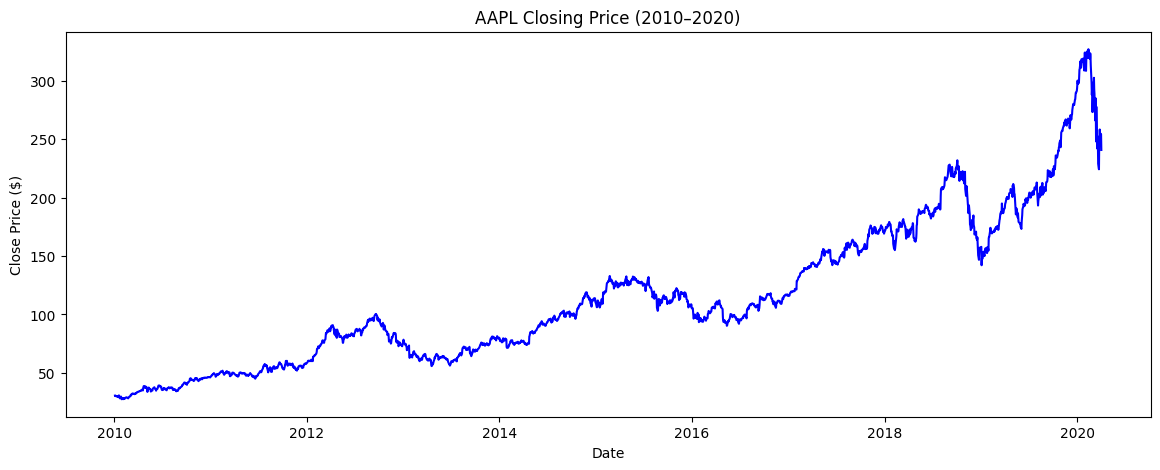

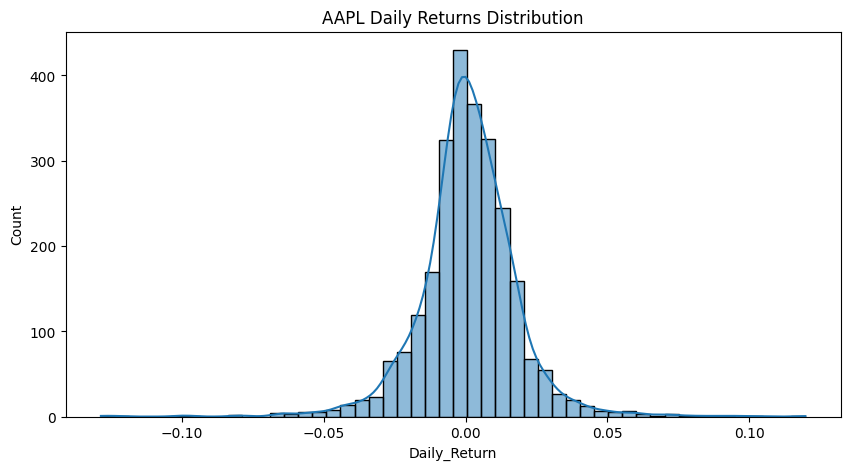

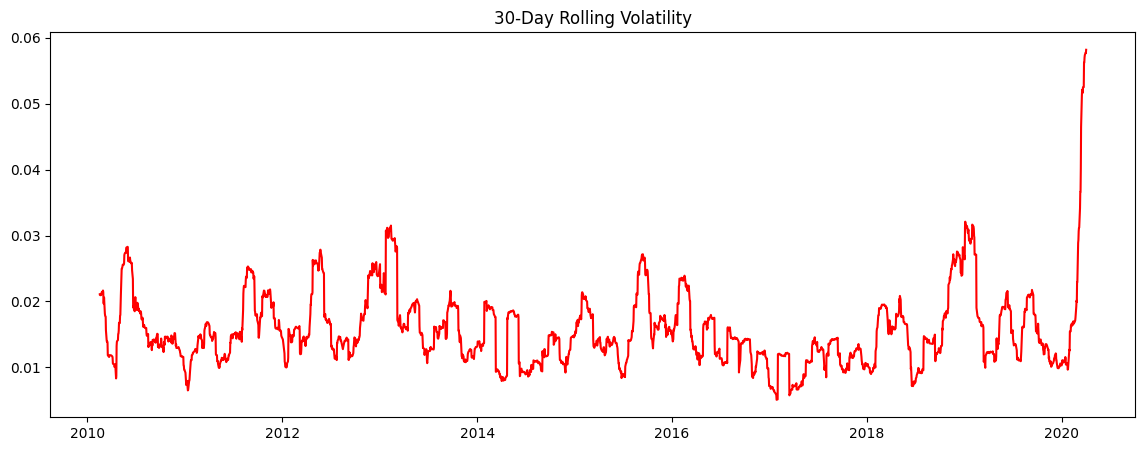

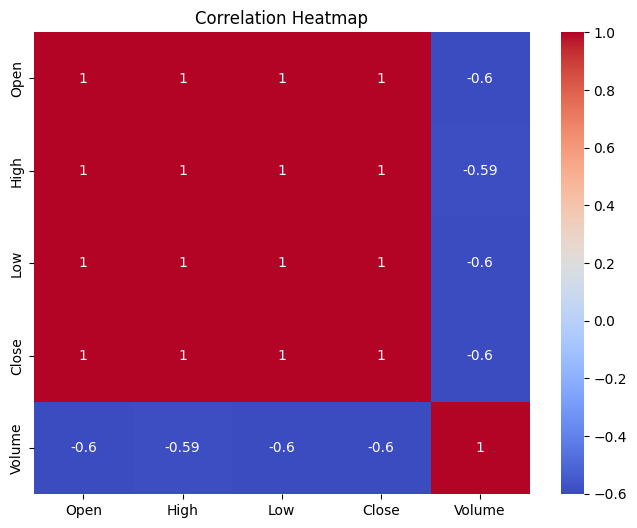

In [12]:
# 3.1 Price trend
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title('AAPL Closing Price (2010–2020)')
plt.xlabel('Date'); plt.ylabel('Close Price ($)')
plt.show()

# 3.2 Daily returns
df['Daily_Return'] = df['Close'].pct_change()
plt.figure(figsize=(10,5))
sns.histplot(df['Daily_Return'].dropna(), bins=50, kde=True)
plt.title('AAPL Daily Returns Distribution')
plt.show()

# 3.3 Volatility
df['Volatility_30'] = df['Daily_Return'].rolling(30).std()
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Volatility_30'], color='red')
plt.title('30-Day Rolling Volatility')
plt.show()

# 3.4 Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# PHASE 4: Feature Engineering

In [13]:
# Moving averages
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_21'] = df['Close'].rolling(window=21).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

# RSI
def calculate_rsi(data, period=14):
    delta = data.diff()
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = calculate_rsi(df['Close'])

# Lag & volatility features
df['Volatility'] = df['Daily_Return'].rolling(window=7).std()
df['Close_Lag1'] = df['Close'].shift(1)
df['Volume_Lag1'] = df['Volume'].shift(1)

# Target: will tomorrow's close be higher than today's?
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df.dropna(inplace=True)
print(df.shape)
print(df[['Date','Close','MA_7','MA_21','RSI','Target']].tail())

(2530, 17)
           Date       Close        MA_7       MA_21        RSI  Target
2574 2020-03-26  258.440002  242.271430  264.943333  43.065694       0
2575 2020-03-27  247.740005  242.424288  263.715715  45.578425       1
2576 2020-03-30  254.809998  243.857145  262.832382  42.224034       0
2577 2020-03-31  254.289993  247.435715  260.712382  44.345175       0
2578 2020-04-01  240.910004  249.798573  258.407144  47.885617       0


# PHASE 5: Train/Test Split

In [14]:
features = ['MA_7', 'MA_21', 'MA_50', 'RSI', 'Volatility', 
            'Close_Lag1', 'Volume_Lag1', 'Volume']

X = df[features]
y = df['Target']

# No shuffling — preserves time order
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Target balance (train):", y_train.value_counts(normalize=True))

Train: (2024, 8) Test: (506, 8)
Target balance (train): Target
1    0.520257
0    0.479743
Name: proportion, dtype: float64


# PHASE 6: Model Training

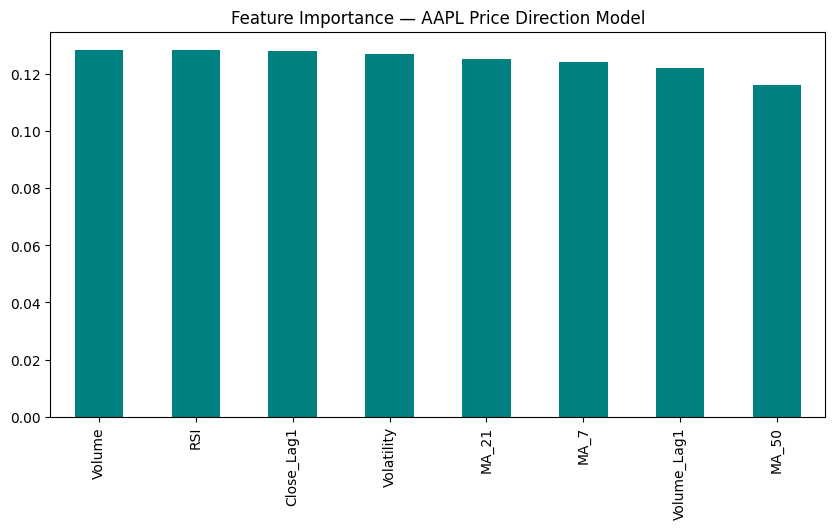

In [15]:
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5), color='teal')
plt.title('Feature Importance — AAPL Price Direction Model')
plt.show()

# PHASE 7: Model Evaluation

Accuracy: 0.4881422924901186
              precision    recall  f1-score   support

           0       0.47      0.90      0.62       231
           1       0.63      0.14      0.23       275

    accuracy                           0.49       506
   macro avg       0.55      0.52      0.42       506
weighted avg       0.56      0.49      0.41       506



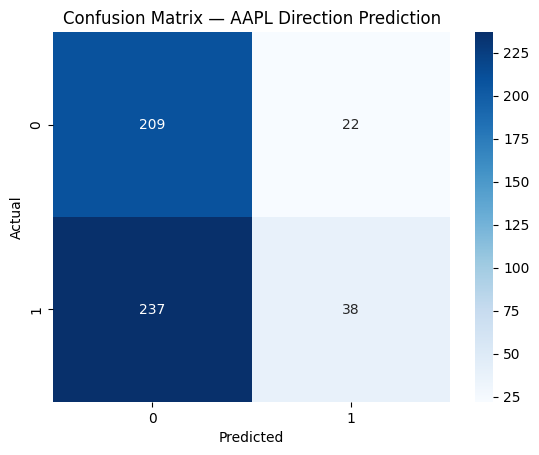

In [16]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — AAPL Direction Prediction')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

# PHASE 8: Visualization

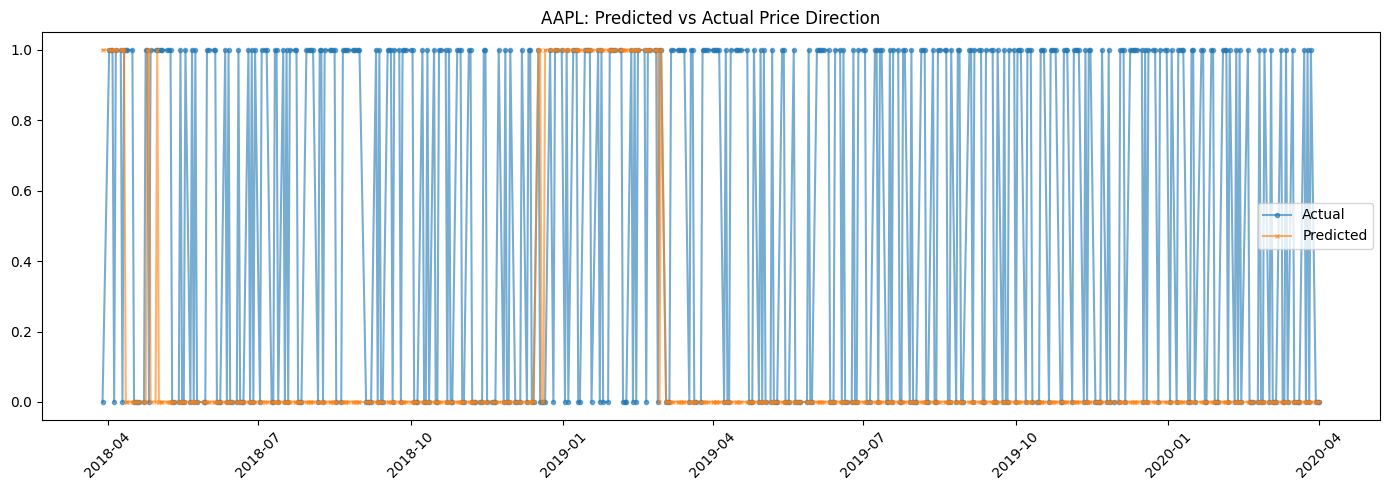

In [17]:
results = pd.DataFrame({
    'Date': df['Date'].iloc[-len(y_test):].values,
    'Actual': y_test.values,
    'Predicted': y_pred
})

plt.figure(figsize=(14,5))
plt.plot(results['Date'], results['Actual'], label='Actual', marker='o', alpha=0.6, markersize=3)
plt.plot(results['Date'], results['Predicted'], label='Predicted', marker='x', alpha=0.6, markersize=3)
plt.title('AAPL: Predicted vs Actual Price Direction')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('aapl_prediction_chart.png')
plt.show()

# Phase 9: Limitations & Conclusion


### Model Performance
- **Algorithm:** Random Forest Classifier (100 trees, max depth 10)
- **Dataset:** AAPL daily price/volume data, 2010–2020 (2,579 trading days)
- **Accuracy:** 48.8% on test set (506 days)
- **Key observation:** The model shows strong bias toward predicting "price down/same" 
  (recall = 0.90 for class 0 vs. 0.14 for class 1), suggesting it has not learned a 
  reliable directional signal and instead defaults toward the majority pattern seen 
  during training.

### Why Accuracy Is Close to Random (≈50%)

This result is consistent with established financial theory rather than a modeling error:

1. **Efficient Market Hypothesis (EMH):** Public price/volume data is rapidly absorbed 
   into stock prices by other market participants. If next-day direction were easily 
   predictable from historical OHLCV data alone, that edge would already be arbitraged away.

2. **Limited feature set:** This model uses only technical indicators (moving averages, 
   RSI, volatility, lagged price/volume). It does not include fundamental data 
   (earnings, news sentiment, macroeconomic indicators), which are known to be stronger 
   drivers of short-term price movement.

3. **Class imbalance in predictions:** The model over-predicts the majority class seen 
   during training, leading to high recall on "down" days but very poor recall on "up" 
   days — a common failure mode when a model finds no strong discriminative signal in 
   the available features.

4. **Short-term direction vs. long-term trend:** Next-day binary direction is one of the 
   hardest targets in financial ML. Models often perform meaningfully better when 
   predicting longer horizons (e.g., 5-day or 30-day trend) or continuous returns rather 
   than next-day direction.

### Risk Factors & Limitations

- This model is built for **educational and analytical purposes only** and should not 
  be used for real trading or investment decisions.
- Stock markets are influenced by unpredictable external events (news, earnings 
  surprises, macroeconomic shocks) not captured in this dataset.
- Past performance and historical patterns do not guarantee future price behavior.
- A near-random accuracy (≈49%) on a binary direction task indicates the model has 
  **no exploitable predictive edge** — this is an expected and well-documented outcome 
  in quantitative finance research, not a flaw in the implementation.

### Recommendations for Future Improvement

1. Incorporate **news sentiment analysis** or earnings calendar data as additional features.
2. Test **longer prediction horizons** (e.g., 5-day or 20-day direction) rather than next-day.
3. Apply **class balancing techniques** (SMOTE, class weights) to address the model's bias 
   toward the majority class.
4. Compare against simpler baselines (e.g., "always predict yesterday's direction continues") 
   to contextualize whether the model adds any value over a naive heuristic.
5. Experiment with other algorithms (XGBoost, LSTM for time-series) and hyperparameter tuning.